# Bubble inference: predict → review in napari → export

Applies your **finalised trained model** (from `bubble_training.ipynb`) to selected frames, frame ranges or whole
trains. You then correct the predictions in napari and export the reviewed bubbles for `bubble_analysis.ipynb`.

1. **Select** frames (section 2).
2. **Predict**: the model's bubbles are written as editable shapes (section 3).
3. **Review** in napari: delete false positives, add missed bubbles, fix outlines, tick **Reviewed** (section 4).
4. **Export** measurements of the reviewed frames (section 5).
5. Retrain: `bubble_training.ipynb` picks up the reviewed frames automatically.

Everything for one run lives in `results/<RUN_NAME>/`:

| file | content |
|---|---|
| `shapes/<frame>.tif`, `shapes/<frame>.json` | frame + bubble outlines (napari ellipses/polygons, overlaps allowed); the editable result |
| `bubbles.csv` | one row per bubble: centre, area, equivalent radius, ellipse axes, edge flags (px and µm) |
| `frames.csv` | one row per frame: train, frame number, bubble counts, reviewed flag |
| `run_info.json`, `export_settings.json` | model and settings used |

Re-running is safe: frames that already have a JSON are never overwritten (so your corrections are kept).

In [1]:
import os, time, dataclasses
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2
import bubble_seg as bs
import bubble_rcnn as br
import bubble_io as bio

import torch
print("torch", torch.__version__, "| CUDA:", torch.cuda.is_available(),
      "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")
plt.rcParams["figure.dpi"] = 90

torch 2.14.1+cu130 | CUDA: True | NVIDIA A100 80GB PCIe


## CONFIG

In [6]:
FRAME_GLOB = "raw/jpg_r571_svd_normalised_tr050/*.jpg"   # all frames of the run
MODEL_PATH = "models/bubble_rcnn_best.pt"                        # your finalised model
RESULTS_ROOT = "results"
RUN_NAME = "r571"                                                # one folder per analysis run
RUN_DIR = os.path.join(RESULTS_ROOT, RUN_NAME)

# inference + measurement settings (override what is stored with the model)
INFER = dict(
    score_thresh=0.5,            # lower -> more bubbles drafted (deleting a false one is quicker than drawing a missed one)
    mask_thresh=0.5,
    mask_nms_iou=0.7,
    um_per_px=3.2,
    # bubbles cut by the image edge: fitted from their visible arc (centre may lie outside the image)
    edge_min_arc_deg=100.0, edge_ellipse_gain=1.6, edge_max_axis_ratio=2.5, edge_reliable_arc_deg=140.0,
    # optional exclusions: rows stay in bubbles.csv with in_analysis=False
    drop_unreliable_fits=False,
    drop_edge_bubbles=False,
    inner_margin=0.0,            # native px: exclude bubbles whose centre is closer than this to the edge
)
DRAFT_KIND = "ellipse"              # "auto": circle, else ellipse, polygon only if neither fits; "polygon" / "ellipse": always that
OVERWRITE_UNREVIEWED = False     # True: re-draft frames that exist but are not reviewed yet (e.g. after retraining)

## 1. Load the model

In [7]:
model, mcfg = br.load_model(MODEL_PATH)
mcfg = dataclasses.replace(mcfg, **INFER)
print(f"loaded {MODEL_PATH} on {next(model.parameters()).device}  (model_scale {mcfg.model_scale}, channels {mcfg.channels})")
bio.write_run_info(RUN_DIR, MODEL_PATH, mcfg)
index = bio.index_frames(FRAME_GLOB)
trains = sorted({t for t, _ in index})
print(f"{len(index)} frames, trains {trains}, results -> {os.path.abspath(RUN_DIR)}")

loaded models/bubble_rcnn_best.pt on cuda:0  (model_scale 3.0, channels ('norm', 'clahe', 'ridge'))
1488 frames, trains [0, 1, 2, 3, 4, 5], results -> /gpfs/exfel/u/usr/SPB/202501/p007699/Shared/sbowie/foam_analysis/results/r571


## 2. Select frames

Mix any of these in `SELECTION`:

| item | meaning |
|---|---|
| `(0, 10)` or `"train0frame010"` / `"tid0_010"` | train 0, frame 10 |
| `(0, [10, 20, 30])` | several frames of train 0 |
| `(0, "10-20")` or `(0, "10-20,30,40-45")` | ranges (end inclusive) |
| `(3, "all")` or `"train3"` | a whole train (248 frames: ~25 min on an A100, and you will only review some) |
| `"all"` | every frame |

The preview uses a fixed grey scale, so over- or under-exposed frames are easy to spot.

6 frames selected: train 0: 1, train 1: 1, train 2: 1, train 3: 1, train 4: 1, train 5: 1


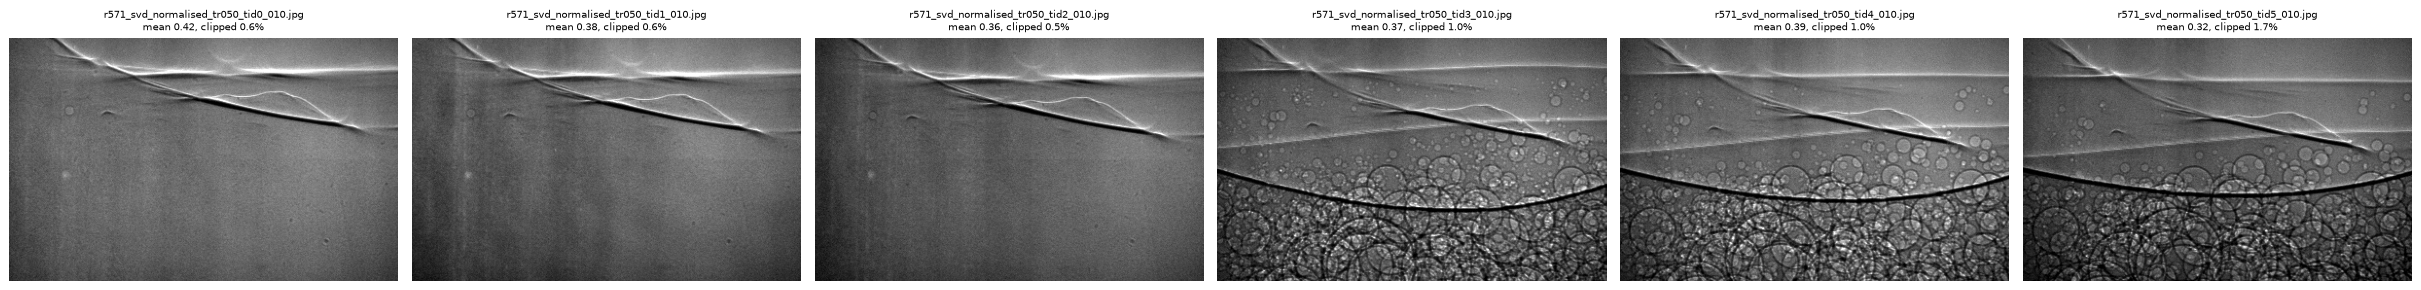

In [8]:
SELECTION = [
    (t, 10) for t in trains          # e.g. one frame per train; edit freely
]
PREVIEW = True

paths = bio.select_frames(SELECTION, index)
if PREVIEW:
    bio.preview_frames(paths)

## 3. Predict and write drafts

Each selected frame gets `shapes/<frame>.tif` + `shapes/<frame>.json` with the model's bubbles.
Frames that already exist are skipped (your edits are safe), unless `OVERWRITE_UNREVIEWED = True` and
the frame is not reviewed yet.

In [9]:
RUN_DRAFT = True
if RUN_DRAFT:
    t = time.time()
    summary = bio.draft_frames(model, mcfg, paths, RUN_DIR, model_path=MODEL_PATH, kind=DRAFT_KIND,
                               overwrite_unreviewed=OVERWRITE_UNREVIEWED, show_every=10)
    print(f"done in {time.time() - t:.0f}s")
    display(summary["status"].value_counts().to_frame())

1/6  r571_svd_normalised_tr050_tid0_010: 4 bubbles  (9s)
6/6  r571_svd_normalised_tr050_tid5_010: 377 bubbles  (95s)
done in 95s


,count
status,
drafted,6


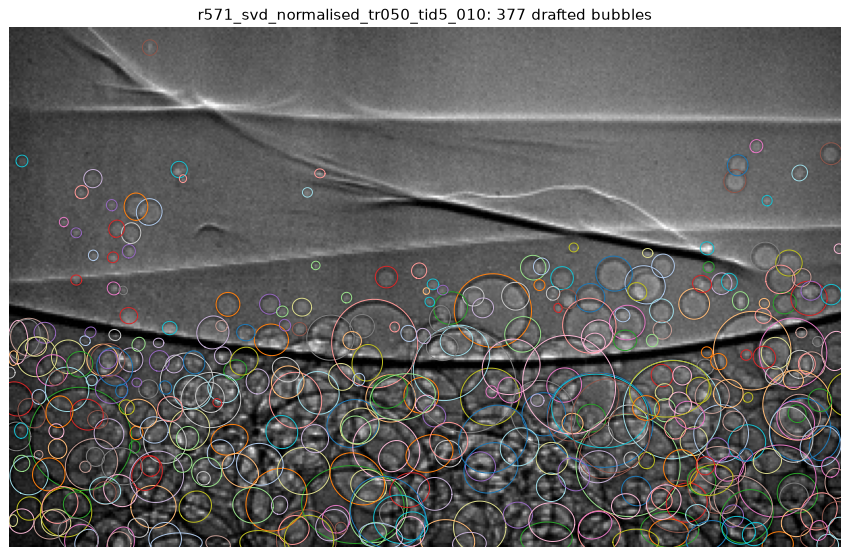

In [12]:
# look at one drafted frame
status = bio.list_results(RUN_DIR)
if len(status):
    show = status.iloc[5]["frame"]
    img, shapes = bio.load_frame(RUN_DIR, show)
    bio.plot_shapes(img, shapes, title=f"{show}: {len(shapes)} drafted bubbles");

## 4. Review in napari (FastX desktop terminal)

```bash
cd /path/to/foam_analysis
python annotate_bubbles.py results/<RUN_NAME>/shapes     # lists frames, Enter = first frame not yet reviewed
```
* **False positive:** select tool (**S**), click the shape, **Delete**.
* **Missed bubble:** **E** ellipse / **P** polygon, full outline including hidden parts. An ellipse may extend beyond
  the image edge; its centre and size are then used exactly.
* **Wrong outline:** select and drag the handles (direct-select **D** moves polygon vertices), or delete and redraw.
* Ignore the *fully annotated* layer here (it is only used for training).
* When the frame is fully checked, tick **Reviewed**. It saves immediately. Then close the window and open the next frame.

Re-run the cell below to see the status.

In [7]:
status = bio.list_results(RUN_DIR)
print(f"{status['reviewed'].sum()} of {len(status)} frames reviewed")
print(f"python annotate_bubbles.py {os.path.join(RUN_DIR, 'shapes')}")
display(status.drop(columns=["json_path"]))

0 of 8 frames reviewed
python annotate_bubbles.py results/r563/shapes


,frame,train,frame_idx,n_bubbles,reviewed,model
0,r563_svd_normalised_tr050_tid0_015,0,15,324,False,bubble_rcnn_best.pt
1,r563_svd_normalised_tr050_tid1_015,1,15,307,False,bubble_rcnn_best.pt
2,r563_svd_normalised_tr050_tid2_015,2,15,297,False,bubble_rcnn_best.pt
3,r563_svd_normalised_tr050_tid3_015,3,15,261,False,bubble_rcnn_best.pt
4,r563_svd_normalised_tr050_tid4_015,4,15,392,False,bubble_rcnn_best.pt
5,r563_svd_normalised_tr050_tid5_015,5,15,397,False,bubble_rcnn_best.pt
6,r563_svd_normalised_tr050_tid6_015,6,15,380,False,bubble_rcnn_best.pt
7,r563_svd_normalised_tr050_tid7_015,7,15,339,False,bubble_rcnn_best.pt


## 5. Export measurements

Measures every reviewed frame with the same rules as the model output and writes `bubbles.csv` and `frames.csv`.
Polygons are measured from their mask; bubbles cut by the image edge are fitted from their visible arc. Drawn
ellipses use their exact parameters. Re-run after any further corrections.

In [8]:
INCLUDE_UNREVIEWED = False       # True: also export frames you have not ticked as reviewed (flagged reviewed=False)

bubbles, frames_tbl = bio.export_results(RUN_DIR, mcfg, include_unreviewed=INCLUDE_UNREVIEWED)
display(frames_tbl)
display(bubbles.round(2).head(10))

8 unreviewed frame(s) left out (include_unreviewed=False)
exported 0 frames, 0 bubbles -> results/r563/bubbles.csv, frames.csv


""


""


In [9]:
# check one exported frame: outlines + measured centres (edge bubbles: centre may be outside the image)
if len(frames_tbl):
    show = frames_tbl.iloc[0]["frame"]
    img, shapes = bio.load_frame(RUN_DIR, show)
    b = bubbles[bubbles["frame"] == show]
    ax = bio.plot_shapes(img, shapes, title=f"{show}: {len(b)} bubbles (dots: centres, x: excluded)", view_pad=30)
    ax.plot(b.loc[b["in_analysis"], "x"], b.loc[b["in_analysis"], "y"], ".", ms=3, color="w")
    ax.plot(b.loc[~b["in_analysis"], "x"], b.loc[~b["in_analysis"], "y"], "x", ms=4, color="0.6")

## 6. *(optional)* Add reviewed frames to the training set now

`bubble_training.ipynb` copies all reviewed frames from `results/` automatically (section 4), so you normally don't
need this. It does the same for this run only: new reviewed frames are copied (whole frame = fully annotated), and
frames you corrected again are updated. Annotations made in `annotations/` itself are never overwritten.

In [10]:
COPY_TO_TRAINING = False
if COPY_TO_TRAINING:
    bio.copy_to_training(RUN_DIR, "annotations")